In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_excel("C:/Users/priya/Downloads/Dataset for Data Analytics (2).xlsx")
df.head(10)                   

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


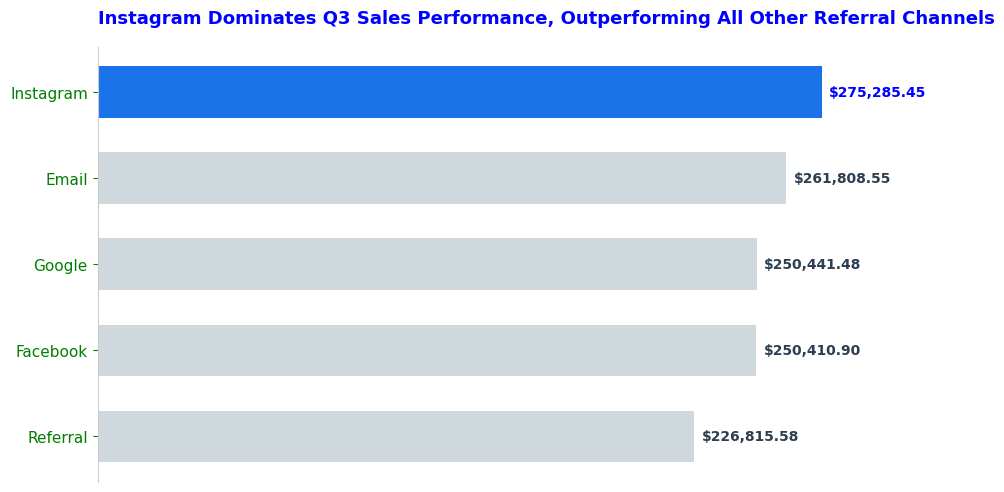

In [19]:
# 1. Aggregate your data by marketing channel
revenue_df = df.groupby("ReferralSource")["TotalPrice"].sum().reset_index()
revenue_df = revenue_df.sort_values(by="TotalPrice", ascending=True)

# 2. Establish Palette (The Spotlight Rule)
max_channel = revenue_df.loc[revenue_df["TotalPrice"].idxmax(), "ReferralSource"]
colors = ["#1a73e8" if x == max_channel else "#cfd8dc" for x in revenue_df["ReferralSource"]]

# 3. Initialize Layout AND Plot together
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
bars = ax.barh(
    revenue_df["ReferralSource"],
    revenue_df["TotalPrice"],
    color=colors,
    height=0.6,
)

# 4. Erase Non-Data Ink (Editor Phase)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.xaxis.set_visible(False)  
ax.tick_params(axis="y", colors="Green", labelsize=11)

# 5. Direct Labeling
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (revenue_df["TotalPrice"].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.2f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="Blue" if bar.get_facecolor() == (26/255, 115/255, 232/255, 1.0) else "#2c3e50"
    )

# 6. Action Title (Storyteller Phase)
ax.text(
    x=0,
    y=len(revenue_df) - 0.2,
    s=f"{max_channel} Dominates Q3 Sales Performance, Outperforming All Other Referral Channels",
    fontsize=13,
    weight="bold",
    color="Blue",
)

plt.tight_layout()
plt.show()